# Reconstructor: VGGT-Omega

---
---
---

# Step 0: Environment Context
Force the working directory to the repository root to ensure configuration files and submodules resolve correctly.

In [1]:
import os
import sys
from pathlib import Path

# Force the working directory to the repository root
if Path.cwd().name == "notebooks":
    os.chdir("..")

# Expose VGGT-Omega modules
vggt_path = Path("external/vggt-omega").resolve()
if str(vggt_path) not in sys.path:
    sys.path.append(str(vggt_path))

# Verify context is now repository root
print(f"Current Working Directory: {Path.cwd()}")

Current Working Directory: /usr/prakt/s0034/AppliedFoundationModels


---
---
---

# Step 1: Initialize model and load weights

In [3]:
import torch
from vggt_omega.models import VGGTOmega
from vggt_omega.utils.load_fn import load_and_preprocess_images
from vggt_omega.utils.pose_enc import encoding_to_camera

checkpoint_path = "external/vggt-omega/checkpoints/vggt_omega_1b_512.pt"

# Initialize and load weights
model = VGGTOmega().to("cuda").eval()
model.load_state_dict(torch.load(checkpoint_path, map_location="cpu", weights_only=True))

<All keys matched successfully>

---
---
---

# Step 2: Choose Input Sequence

## DATASET: ScanNet

---

### scene0004_00:
sceneType = Hallway

numColorFrames = 929

In [5]:
input_sequence_dir = Path("/storage/group/dataset_mirrors/scannet/scans/scene0004_00/color")
output_results_dir_base = Path("data/reconstruction/vggt_omega_output/scannet/scene0004_00")

---

---
---
---

# Step 3: Generate custom config for target sequence

In [6]:
config_number = "00"
config_filename = f"custom_3DRoomSearch_v{config_number}.yaml"

In [7]:
abs_input_pattern = f"{input_sequence_dir.resolve()}/*.jpg" # ScanNet
# abs_input_pattern = f"{input_sequence_dir.resolve()}/*.png" # TUM RGB-D

abs_output_dir = (output_results_dir_base / f"config_{config_number}").resolve()
abs_output_dir.mkdir(parents=True, exist_ok=True)
abs_config_path = (abs_output_dir / f"{config_filename}").resolve()

In [8]:
stride = 10
max_frames = 10

### Quick check of resulting input sequence for current config

Visualizing 10 frames (Stride: 10)


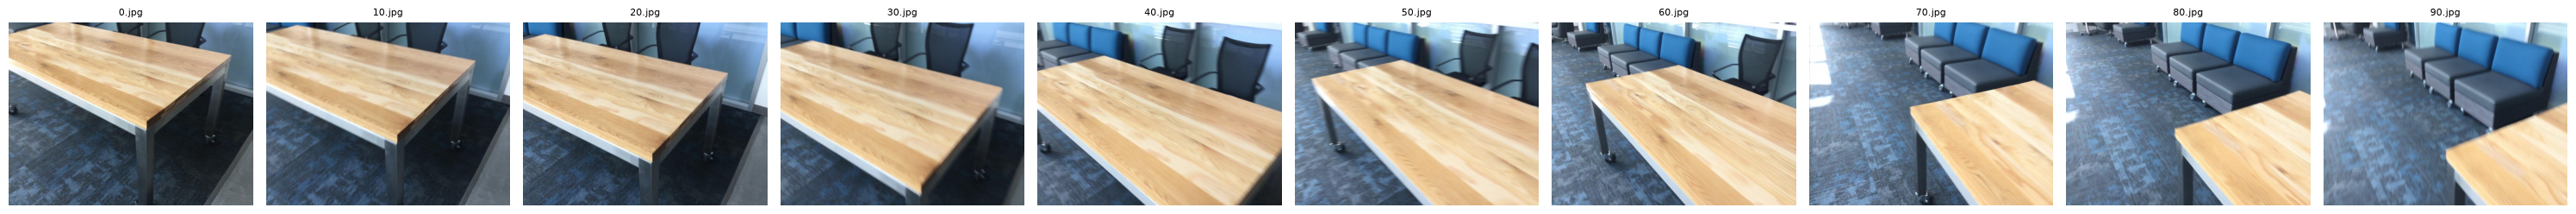

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

# Parse sequence and apply strict numerical sorting
all_images = sorted(
    list(input_sequence_dir.glob("*.jpg")), 
    key=lambda x: int(x.stem)
)

sampled_paths = all_images[::stride][:max_frames]
image_names = [str(p) for p in sampled_paths]

print(f"Visualizing {len(image_names)} frames (Stride: {stride})")

# Render
fig, axes = plt.subplots(1, len(image_names), figsize=(3 * len(image_names), 3))
if len(image_names) == 1:
    axes = [axes]

for ax, img_path in zip(axes, image_names):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(Path(img_path).name, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Define the configuration as a multi-line Python f-string
config_content = f"""# ViSTA-SLAM Custom Configuration v{config_number}
stride: {stride}
max_frames: {max_frames}
"""

# Write the string directly to the absolute path
abs_config_path.write_text(config_content)

print(f"✅ Generated custom configuration: {abs_config_path.name}")

✅ Generated custom configuration: custom_3DRoomSearch_v00.yaml


---
---
---

# Step 4: Invoke VGGT-Omega

In [13]:
# Load and preprocess using the correct, numerically sorted frame paths
images = load_and_preprocess_images(image_names, image_resolution=512).to("cuda")

print(f"Preprocessed tensor shape: {images.shape}")  # Expected: [B, C, H, W]

Preprocessed tensor shape: torch.Size([10, 3, 448, 592])


In [20]:
with torch.inference_mode():
    predictions = model(images)

# Decode camera parameters and append directly to the predictions dictionary
extrinsics, intrinsics = encoding_to_camera(
    predictions["pose_enc"],
    predictions["images"].shape[-2:],
)
predictions["extrinsics"] = extrinsics
predictions["intrinsics"] = intrinsics

print(f"Successfully processed {len(image_names)} frames.")
print(f"Available prediction outputs: {list(predictions.keys())}")

Successfully processed 10 frames.
Available prediction outputs: ['camera_and_register_tokens', 'pose_enc', 'depth', 'depth_conf', 'images', 'extrinsics', 'intrinsics']


### (optional: check shapes)

In [21]:
print("--- Raw Tensor Shapes ---")
print(f"Depth:      {predictions['depth'].shape}")
print(f"Confidence: {predictions['depth_conf'].shape}")
print(f"Extrinsics: {predictions['extrinsics'].shape}")
print(f"Intrinsics: {predictions['intrinsics'].shape}")
print(f"Sequence:   {len(image_names)} frames")

--- Raw Tensor Shapes ---
Depth:      torch.Size([1, 10, 448, 592, 1])
Confidence: torch.Size([1, 10, 448, 592])
Extrinsics: torch.Size([1, 10, 3, 4])
Intrinsics: torch.Size([1, 10, 3, 3])
Sequence:   10 frames


In [ ]:
import json
import torch
import numpy as np
import open3d as o3d
from PIL import Image

output_tensors_file = abs_output_dir / "vggt_predictions.pt"
output_names_file = abs_output_dir / "image_names.json"
output_pcd_file = abs_output_dir / "global_pointcloud.ply"

# Move predictions to CPU once
depth_cpu = predictions["depth"].cpu()
depth_conf_cpu = predictions["depth_conf"].cpu()
ext_cpu = predictions["extrinsics"].cpu()
int_cpu = predictions["intrinsics"].cpu()

# 1. Store model tensor outputs
tensor_dict = {
    "depth": depth_cpu,
    "depth_conf": depth_conf_cpu,
    "extrinsics": ext_cpu,
    "intrinsics": int_cpu,
}
torch.save(tensor_dict, output_tensors_file)
print(f"Saved tensor predictions to: {output_tensors_file.name}")

# 2. Store sequence metadata separately
with open(output_names_file, "w") as f:
    json.dump(image_names, f, indent=4)
print(f"Saved image names to: {output_names_file.name}")

# 3. Generate and store global point cloud
# Strip Batch dimension (0) and trailing Channel dimension (-1) from depth
depths = depth_cpu.squeeze(-1)[0]       # [10, 448, 592]
confs = depth_conf_cpu[0]               # [10, 448, 592]
exts = ext_cpu[0]                       # [10, 3, 4]
ints = int_cpu[0]                       # [10, 3, 3]

N, H, W = depths.shape
conf_thresh = 0.5 

# Generate unprojection grid
v, u = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
uv = torch.stack([u, v], dim=-1).float()       # [H, W, 2]

global_points = []
global_colors = []

for i in range(N):
    depth = depths[i]
    conf = confs[i]
    K = ints[i]
    T_cw = exts[i]

    # Pad to 4x4 and invert to Camera-to-World
    T_cw_4x4 = torch.eye(4)
    T_cw_4x4[:3, :4] = T_cw
    T_wc = torch.linalg.inv(T_cw_4x4)[:3, :4]

    # Filter invalid/low-confidence geometry
    mask = (conf > conf_thresh) & (depth > 0)
    z = depth[mask]
    uv_valid = uv[mask]

    # Pinhole unprojection to local frame C: Pc = [X, Y, Z, 1]^T
    x = (uv_valid[:, 0] - K[0, 2]) * z / K[0, 0]
    y = (uv_valid[:, 1] - K[1, 2]) * z / K[1, 1]
    pts_local = torch.stack([x, y, z, torch.ones_like(z)], dim=-1) # [M, 4]

    # SE(3) transformation to global frame W using the inverted matrix
    pts_global = (T_wc @ pts_local.T).T
    global_points.append(pts_global)

    # Extract aligned RGB values
    img = np.array(Image.open(image_names[i]).resize((W, H)))
    colors = torch.from_numpy(img).float() / 255.0
    global_colors.append(colors[mask])

# Fuse and export
all_points = torch.cat(global_points, dim=0).numpy()
all_colors = torch.cat(global_colors, dim=0).numpy()

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(all_points)
pcd.colors = o3d.utility.Vector3dVector(all_colors)

o3d.io.write_point_cloud(str(output_pcd_file), pcd)
print(f"✅ Fused global pointcloud saved to: {output_pcd_file.name}")

Saved tensor predictions to: vggt_predictions.pt
Saved image names to: image_names.json
✅ Fused global pointcloud saved to: global_pointcloud.ply
